# Visual Demo: LIME Explanations for Calibrated vs Uncalibrated Models

This notebook creates visual examples comparing LIME explanations between uncalibrated and MCal-calibrated models on MRI data.

**Goal**: Show side-by-side visualizations of how MCal changes the LIME importance scores.

## 1. Setup and Imports

In [1]:
# Notebooks run from their own folder; make the repository root importable.
import sys, pathlib

import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from tqdm import tqdm
import timm
from pathlib import Path
import os

# Add parent directory to path

# Import dataset classes and components
from experiments.all_data_loaders import MRIPatchedProbDataset, MRICleanDataset
from mcal.calibrators.mcal_ce import SimpleMCalCE
from experiments.explanations import ImageLIME

# Set device
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device("cuda:3")
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda:3


## 2. Configuration

In [2]:
config = {
    'n_train': 2000,           # Number of training samples for MCal
    'n_test': 16,              # Number of test images to visualize
    'ablation_rate': 0.5,      # Probability of ablating each patch
    'patch_size': 56,          # Patch size matching vanilla model training
    'mcal_steps': 5000,        # Training steps for MCal
    'lime_samples': 200,       # Number of samples for LIME
    'batch_size': 32,
    'device': device
}

print("Configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")

Configuration:
  n_train: 2000
  n_test: 16
  ablation_rate: 0.5
  patch_size: 56
  mcal_steps: 5000
  lime_samples: 200
  batch_size: 32
  device: cuda:3


## 3. Load MRI Model

In [3]:
# Load the vanilla MRI model (trained without ablations)
model_path = Path('../saved_models/vit_timm_standard_mri_ps64_35e.pth')

if not model_path.exists():
    # Try alternative path
    model_path = Path.cwd().parent / 'saved_models' / 'vit_timm_standard_mri_ps64_35e.pth'
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found at: {model_path}")

print(f"Loading vanilla model from: {model_path}")

# Create model architecture
base_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=4)

# Load the state dict
state_dict = torch.load(model_path, map_location=device)
base_model.load_state_dict(state_dict)

base_model = base_model.to(device)
base_model.eval()
uncal_model = base_model

print("✓ Loaded vanilla MRI model (trained on clean data only)")
print("  This model should have missingness bias that MCal can fix")

Loading vanilla model from: ../saved_models/vit_timm_standard_mri_ps64_35e.pth
✓ Loaded vanilla MRI model (trained on clean data only)
  This model should have missingness bias that MCal can fix


## 4. Load Test Data

In [4]:
# Load test dataset and select 4 samples from each class
print("Loading test dataset and selecting balanced samples...")

# Load full test dataset
test_dataset_full = MRICleanDataset(split='test', n_samples=None)
test_loader_full = DataLoader(test_dataset_full, batch_size=len(test_dataset_full), shuffle=False)

# Load all test images
all_test_images, all_test_labels = next(iter(test_loader_full))

# Select 4 samples from each class
n_per_class = 4
n_classes = 4
selected_indices = []

for class_idx in range(n_classes):
    # Find all indices for this class
    class_indices = torch.where(all_test_labels == class_idx)[0].numpy()
    
    # Randomly select n_per_class samples from this class
    if len(class_indices) >= n_per_class:
        selected = np.random.choice(class_indices, size=n_per_class, replace=False)
        selected_indices.extend(selected.tolist())
    else:
        # If not enough samples, take all available
        selected_indices.extend(class_indices.tolist())
        print(f"  Warning: Only {len(class_indices)} samples available for class {class_idx}")

# Sort indices to keep samples in a reasonable order
selected_indices = sorted(selected_indices)

# Extract selected samples
test_images = all_test_images[selected_indices].to(device)
test_labels = all_test_labels[selected_indices].to(device)

print(f"Selected {len(test_images)} test images (balanced across classes)")
print(f"  Shape: {test_images.shape}")
print(f"  Labels: {test_labels.cpu().numpy()}")
print(f"  Label distribution: {torch.bincount(test_labels).cpu().numpy()}")
print(f"  Selected indices: {selected_indices}")

Loading test dataset and selecting balanced samples...
Selected 16 test images (balanced across classes)
  Shape: torch.Size([16, 3, 224, 224])
  Labels: [0 0 0 0 1 1 1 1 2 2 2 2 3 3 3 3]
  Label distribution: [4 4 4 4]
  Selected indices: [9, 152, 203, 266, 371, 377, 492, 513, 784, 803, 850, 1004, 1013, 1117, 1262, 1286]


## 5. Train MCal Calibrator

In [5]:
# Create training dataset with ablations
train_ablated_dataset = MRIPatchedProbDataset(
    split='train',
    n_samples=config['n_train'],
    p_ablate=config['ablation_rate'],
    patch_size=config['patch_size'],
    seed=42
)
train_ablated_loader = DataLoader(
    train_ablated_dataset, 
    batch_size=config['batch_size'], 
    shuffle=False
)

# Get labels and ablated predictions for training
print("Computing predictions on ablated training data...")
train_labels = []
ablated_logits = []

with torch.no_grad():
    for images, labels in tqdm(train_ablated_loader, desc="Computing predictions"):
        images = images.to(device)
        labels = labels.to(device)
        train_labels.append(labels)
        ablated_logits.append(base_model(images))
    
    train_labels = torch.cat(train_labels)
    ablated_logits = torch.cat(ablated_logits)

# Train MCal calibrator
print("\nTraining MCal calibrator...")
calibrator = SimpleMCalCE(num_classes=4).to(device)
stats = calibrator.fit(
    ablated_logits=ablated_logits,
    target_labels=train_labels,
    verbose=True
)

print(f"\n✓ Training complete!")
print(f"  Final Loss: {stats['loss'][-1]:.4f}")
print(f"  Final Accuracy: {stats['acc'][-1]:.3f}")

Computing predictions on ablated training data...


Computing predictions: 100%|██████████| 63/63 [00:06<00:00,  9.36it/s]



Training MCal calibrator...


Loss: 1.825e-01, Acc: 0.927: 100%|██████████| 5000/5000 [00:12<00:00, 410.65it/s]


✓ Training complete!
  Final Loss: 0.1825
  Final Accuracy: 0.927


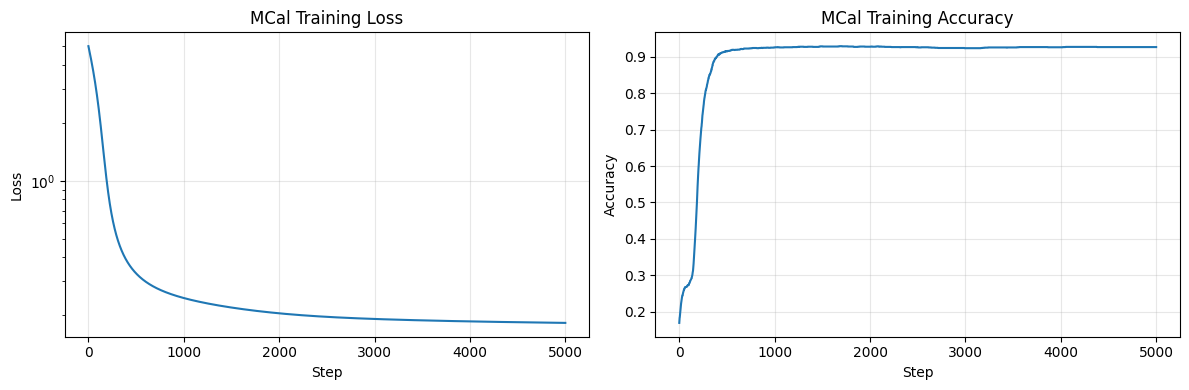

In [6]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(stats['loss'])
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('MCal Training Loss')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

ax2.plot(stats['acc'])
ax2.set_xlabel('Step')
ax2.set_ylabel('Accuracy')
ax2.set_title('MCal Training Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Create calibrated model
calib_model = nn.Sequential(base_model, calibrator)
calib_model.eval()

print("✓ Calibrated model created")

✓ Calibrated model created


## 6. Generate LIME Explanations

In [8]:
# Initialize LIME explainers
print("Initializing LIME explainers...")

uncal_lime_explainer = ImageLIME(
    model=uncal_model,
    num_samples=config['lime_samples'],
    patch_size=config['patch_size'],
    image_size=224
)

calib_lime_explainer = ImageLIME(
    model=calib_model,
    num_samples=config['lime_samples'],
    patch_size=config['patch_size'],
    image_size=224
)

print(f"✓ LIME explainers initialized with {config['lime_samples']} samples")

Initializing LIME explainers...
✓ LIME explainers initialized with 200 samples


In [9]:
# Generate LIME explanations for all test images
print(f"\nGenerating LIME explanations for {len(test_images)} test images...")

uncal_lime_attrs = []
calib_lime_attrs = []

for i, (image, label) in enumerate(tqdm(zip(test_images, test_labels), 
                                        total=len(test_images), 
                                        desc="LIME explanations")):
    uncal_lime_attrs.append(uncal_lime_explainer.explain_instance(image, label.item()))
    calib_lime_attrs.append(calib_lime_explainer.explain_instance(image, label.item()))

print("✓ LIME explanations generated for all test images")


Generating LIME explanations for 16 test images...


LIME explanations: 100%|██████████| 16/16 [01:32<00:00,  5.78s/it]

✓ LIME explanations generated for all test images


## 7. Visualization Helper Function

In [10]:
def create_heatmap_overlay(image, importance_scores, patch_size=64, alpha=0.6, cmap='RdBu_r'):
    """
    Create a heatmap overlay on the original image.
    
    Args:
        image: Original image tensor (C, H, W)
        importance_scores: LIME importance scores (n_patches,)
        patch_size: Size of each patch
        alpha: Transparency of heatmap overlay
        cmap: Colormap to use
    
    Returns:
        overlaid_image: Image with heatmap overlay (H, W, 3)
    """
    # Convert image to numpy (H, W, C)
    img_np = image.cpu().permute(1, 2, 0).numpy()
    
    # Normalize image to [0, 1]
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    
    # Create heatmap
    H, W = img_np.shape[:2]
    n_patches_per_dim = H // patch_size
    heatmap = np.zeros((H, W))
    
    # Normalize importance scores
    importance_np = importance_scores.cpu().numpy()
    vmax = np.abs(importance_np).max()
    importance_normalized = importance_np / (vmax + 1e-8)
    
    # Fill heatmap with patch importance scores
    patch_idx = 0
    for i in range(n_patches_per_dim):
        for j in range(n_patches_per_dim):
            if patch_idx < len(importance_normalized):
                row_start = i * patch_size
                row_end = min(row_start + patch_size, H)
                col_start = j * patch_size
                col_end = min(col_start + patch_size, W)
                
                heatmap[row_start:row_end, col_start:col_end] = importance_normalized[patch_idx]
                patch_idx += 1
    
    # Apply colormap
    colormap = cm.get_cmap(cmap)
    heatmap_colored = colormap((heatmap + 1) / 2)[:, :, :3]  # Normalize to [0, 1] for colormap
    
    # Overlay heatmap on image
    overlaid = (1 - alpha) * img_np + alpha * heatmap_colored
    overlaid = np.clip(overlaid, 0, 1)
    
    return overlaid, heatmap


def visualize_lime_comparison(idx, image, label, uncal_importance, calib_importance, 
                              uncal_model, calib_model, patch_size=64):
    """
    Create a 1x4 visualization comparing uncalibrated vs calibrated LIME explanations.
    
    Args:
        idx: Image index
        image: Original image tensor (C, H, W)
        label: True label
        uncal_importance: Uncalibrated LIME importance scores
        calib_importance: Calibrated LIME importance scores
        uncal_model: Uncalibrated model
        calib_model: Calibrated model
        patch_size: Size of each patch
    """
    # Get predictions
    with torch.no_grad():
        uncal_pred = torch.softmax(uncal_model(image.unsqueeze(0)), dim=1)
        calib_pred = torch.softmax(calib_model(image.unsqueeze(0)), dim=1)
    
    # Create figure
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # Original image
    img_np = image.cpu().permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    axes[0].imshow(img_np)
    axes[0].set_title(f"Original Image\nTrue Label: {label.item()}")
    axes[0].axis('off')
    
    # Uncalibrated LIME heatmap
    uncal_overlay, _ = create_heatmap_overlay(image, uncal_importance, patch_size)
    axes[1].imshow(uncal_overlay)
    uncal_pred_str = ', '.join([f'{p:.2f}' for p in uncal_pred[0].cpu().numpy()])
    axes[1].set_title(f"Uncalibrated LIME\nPred: [{uncal_pred_str}]")
    axes[1].axis('off')
    
    # Calibrated LIME heatmap
    calib_overlay, _ = create_heatmap_overlay(image, calib_importance, patch_size)
    axes[2].imshow(calib_overlay)
    calib_pred_str = ', '.join([f'{p:.2f}' for p in calib_pred[0].cpu().numpy()])
    axes[2].set_title(f"MCal Calibrated LIME\nPred: [{calib_pred_str}]")
    axes[2].axis('off')
    
    # Difference heatmap
    diff_importance = calib_importance - uncal_importance
    diff_overlay, diff_heatmap = create_heatmap_overlay(image, diff_importance, patch_size)
    im = axes[3].imshow(diff_heatmap, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[3].set_title(f"Difference\n(Calibrated - Uncalibrated)")
    axes[3].axis('off')
    
    # Add colorbar for difference
    cbar = plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
    cbar.set_label('Importance Change', rotation=270, labelpad=15)
    
    plt.tight_layout()
    
    return fig

print("✓ Visualization functions defined")

✓ Visualization functions defined


## 8. Generate Visual Examples

In [11]:
# Create output directory
output_dir = Path('results/lime_visual_examples')
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving visualizations to: {output_dir.absolute()}")
print("\n" + "="*60)

Saving visualizations to: /ssd1/ayx98/MCal/experiments/results/lime_visual_examples



/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)



Generating visualization for image 1/16...
  ✓ Saved: results/lime_visual_examples/lime_comparison_image_00.pdf


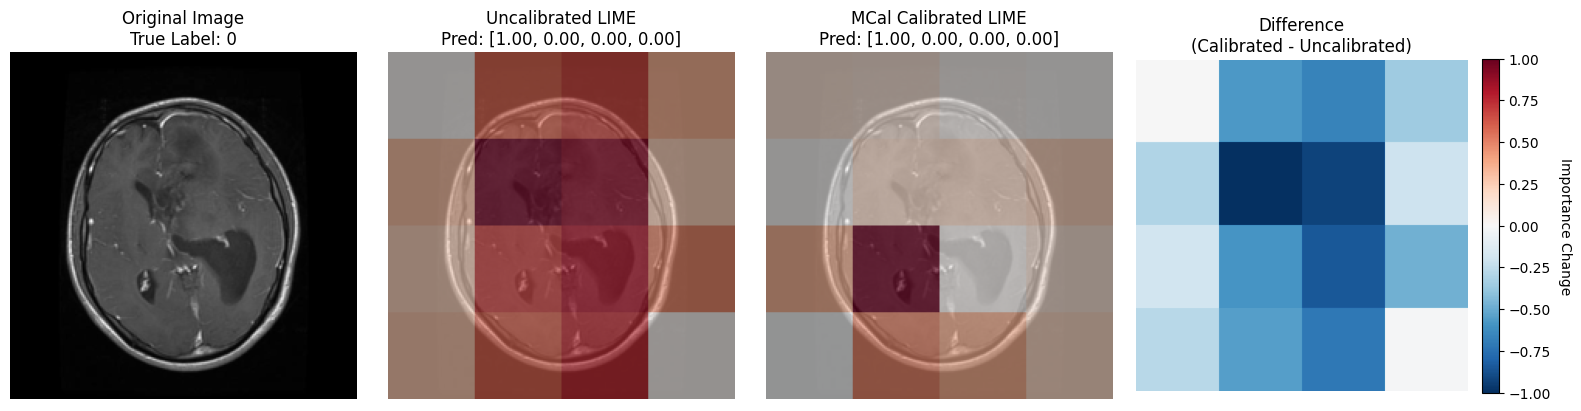


Generating visualization for image 2/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_01.pdf


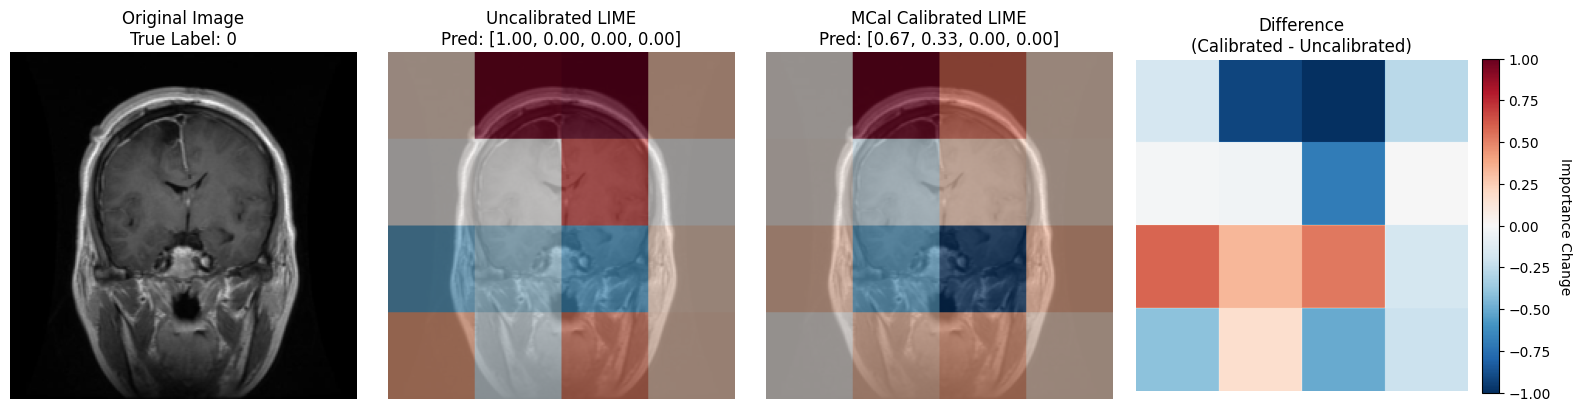


Generating visualization for image 3/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_02.pdf


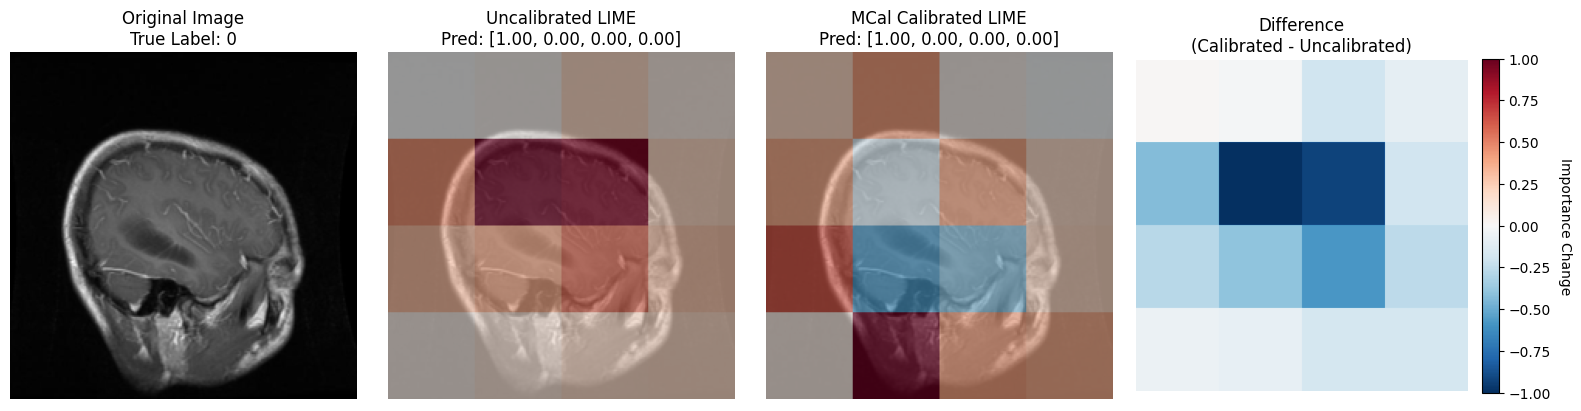


Generating visualization for image 4/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_03.pdf


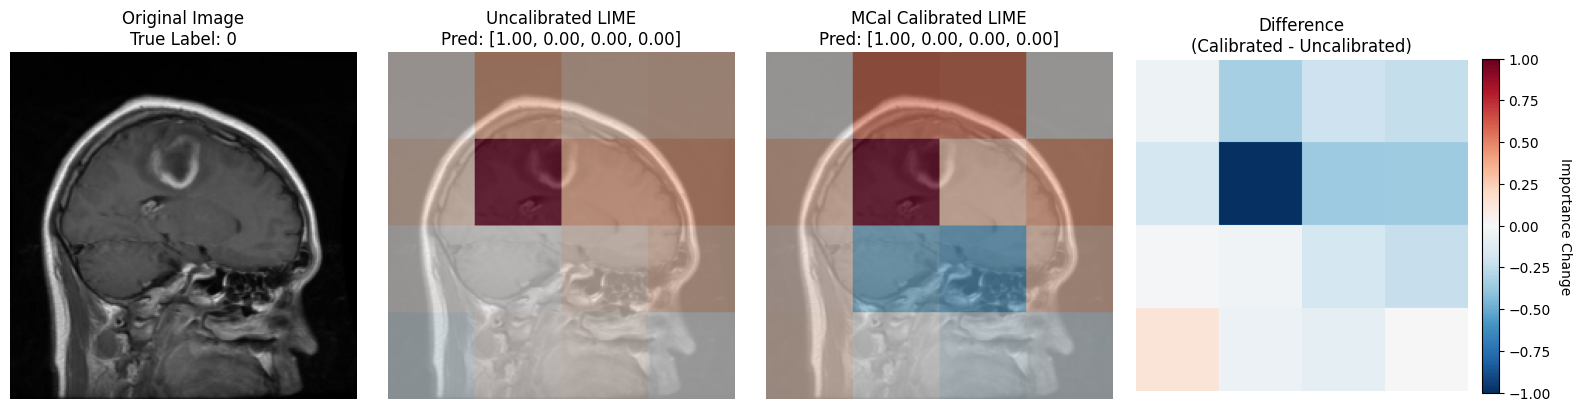


Generating visualization for image 5/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_04.pdf


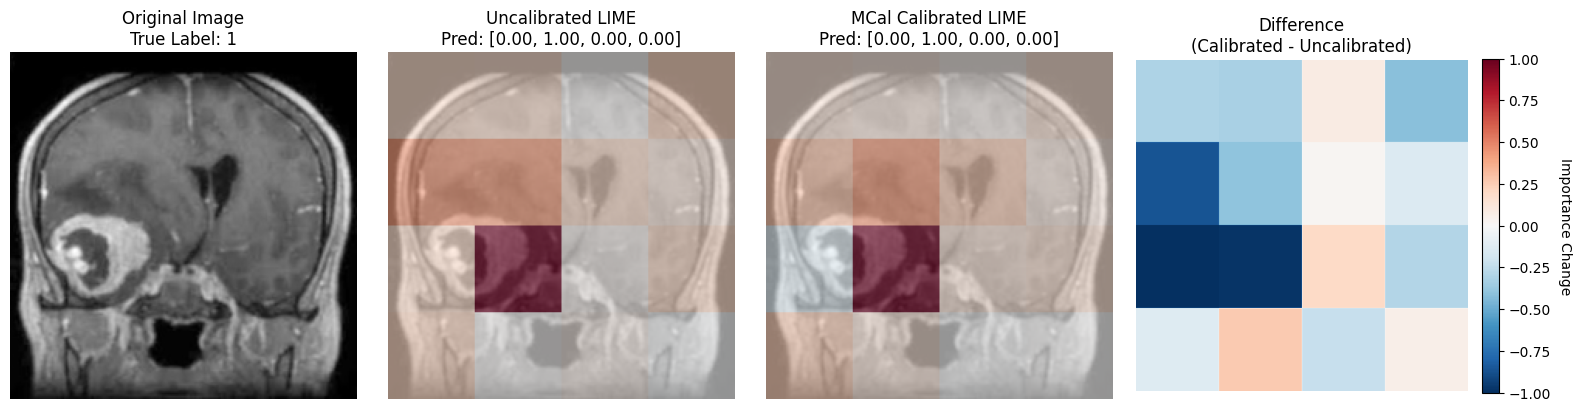


Generating visualization for image 6/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_05.pdf


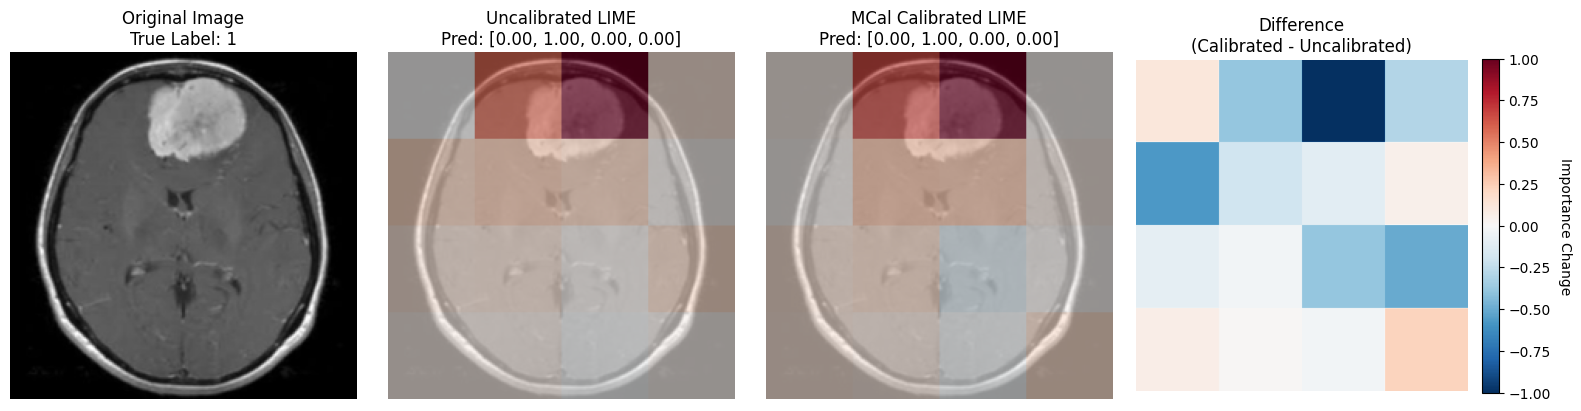


Generating visualization for image 7/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_06.pdf


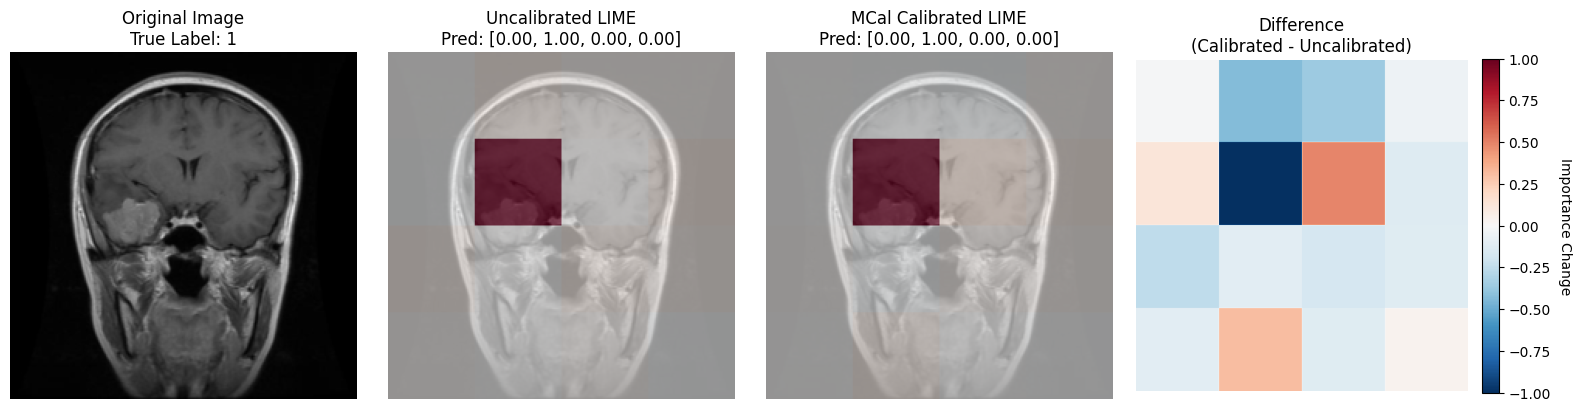


Generating visualization for image 8/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_07.pdf


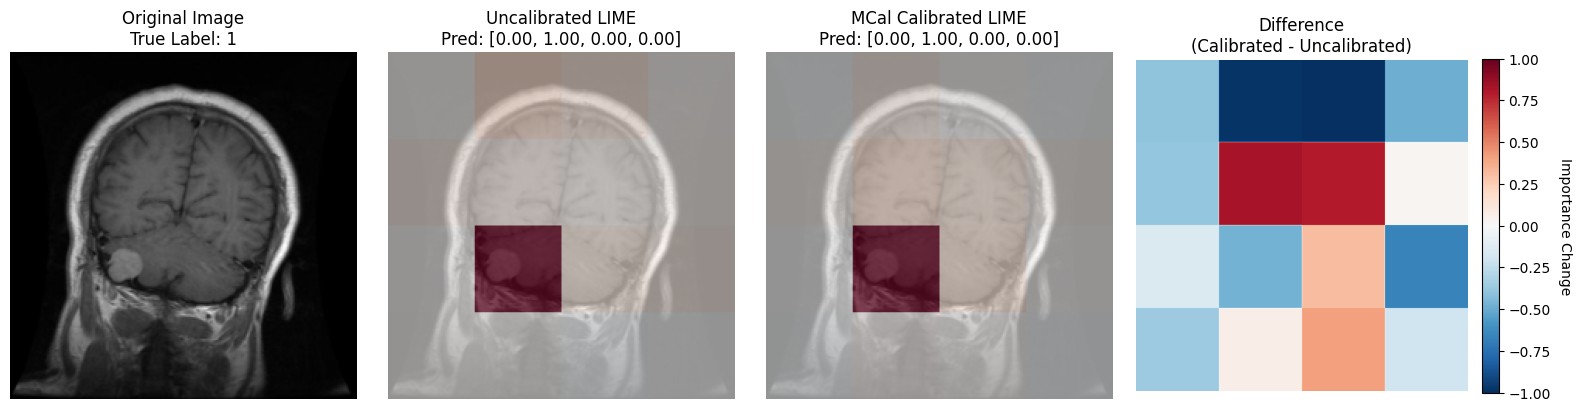


Generating visualization for image 9/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_08.pdf


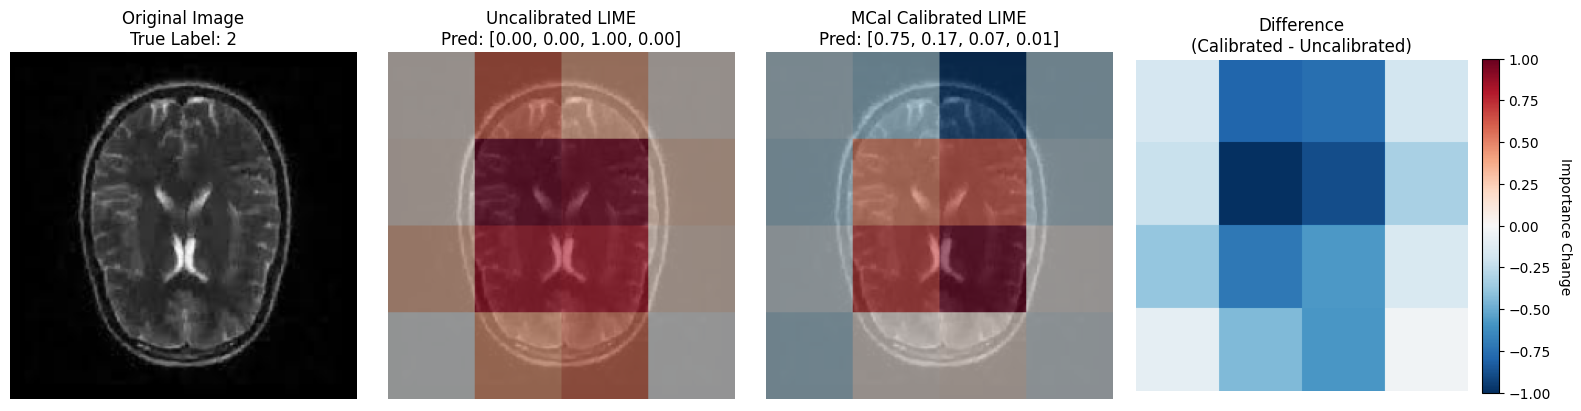


Generating visualization for image 10/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_09.pdf


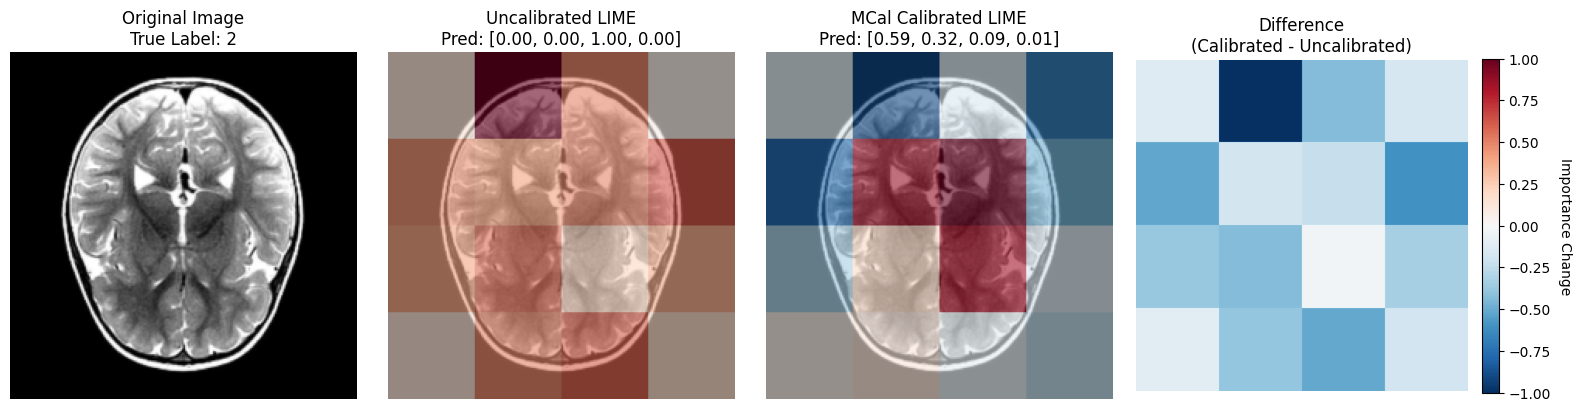


Generating visualization for image 11/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_10.pdf


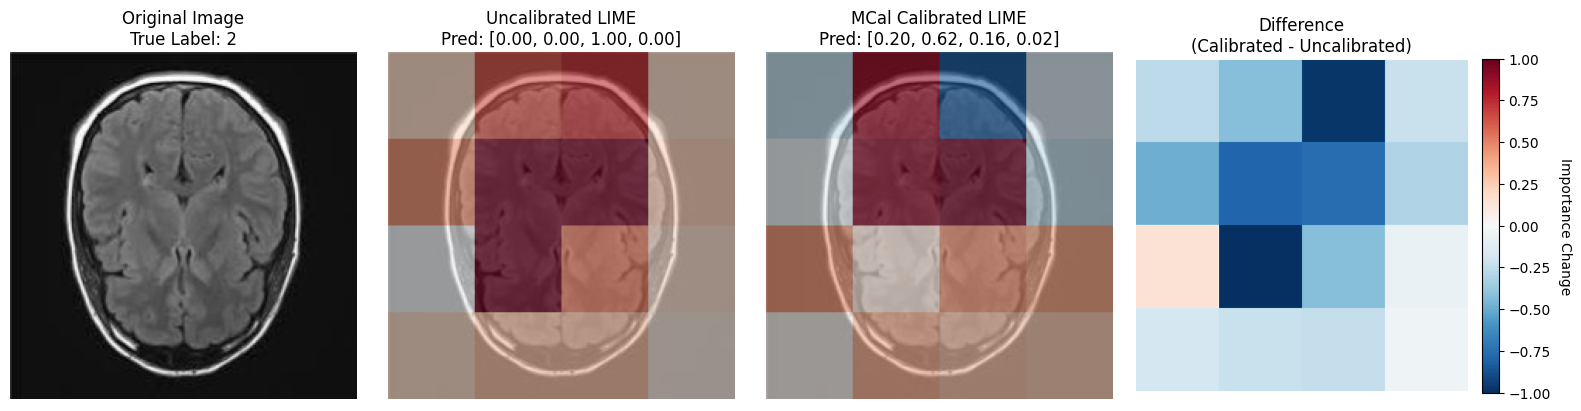


Generating visualization for image 12/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_11.pdf


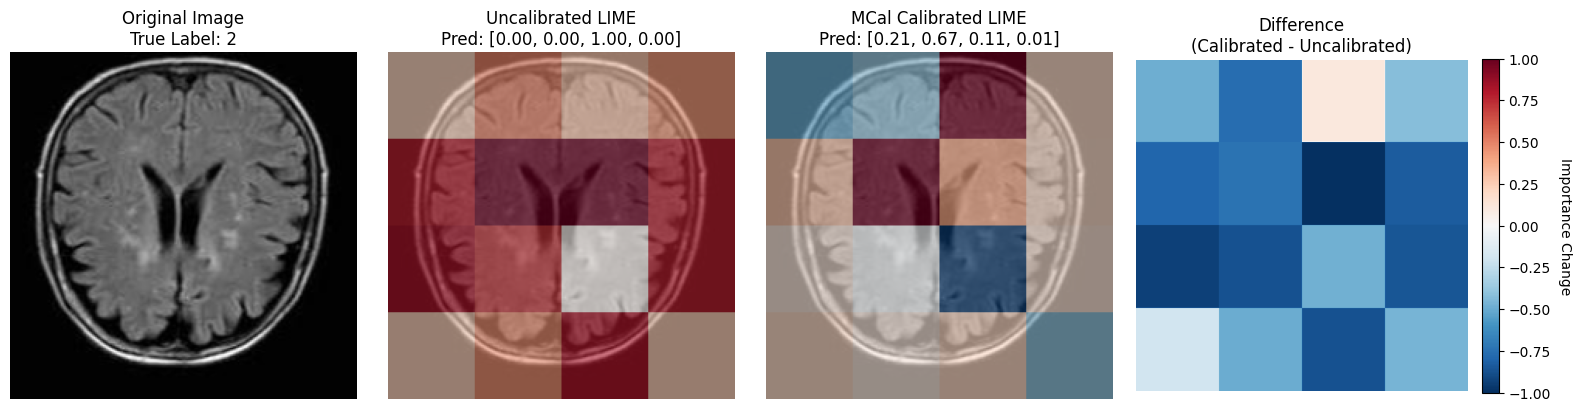


Generating visualization for image 13/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_12.pdf


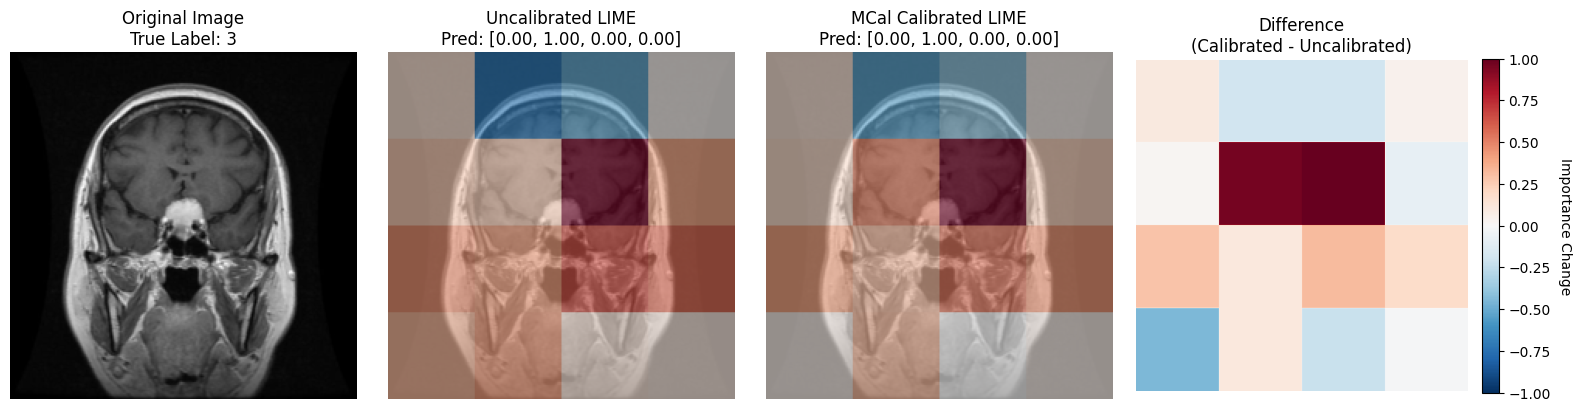


Generating visualization for image 14/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_13.pdf


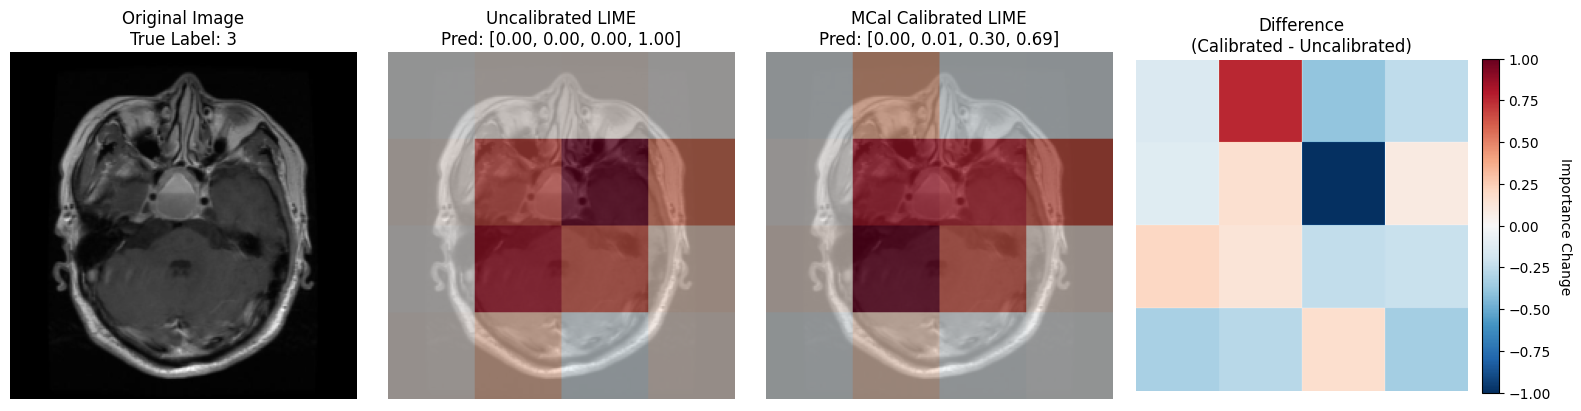


Generating visualization for image 15/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_14.pdf


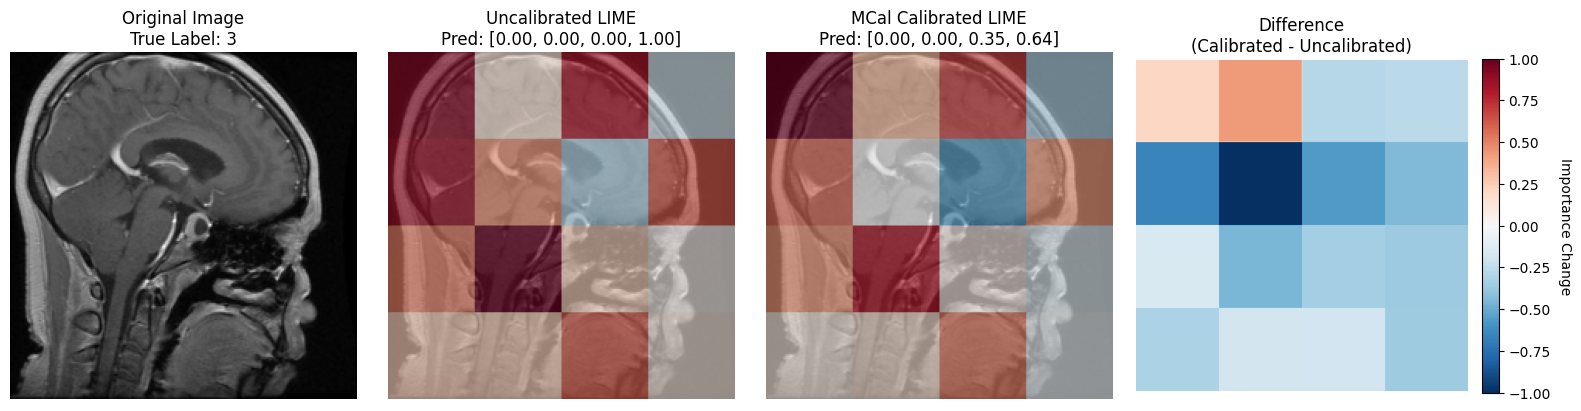


Generating visualization for image 16/16...


/tmp/ipykernel_1597408/1464051619.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap(cmap)


  ✓ Saved: results/lime_visual_examples/lime_comparison_image_15.pdf


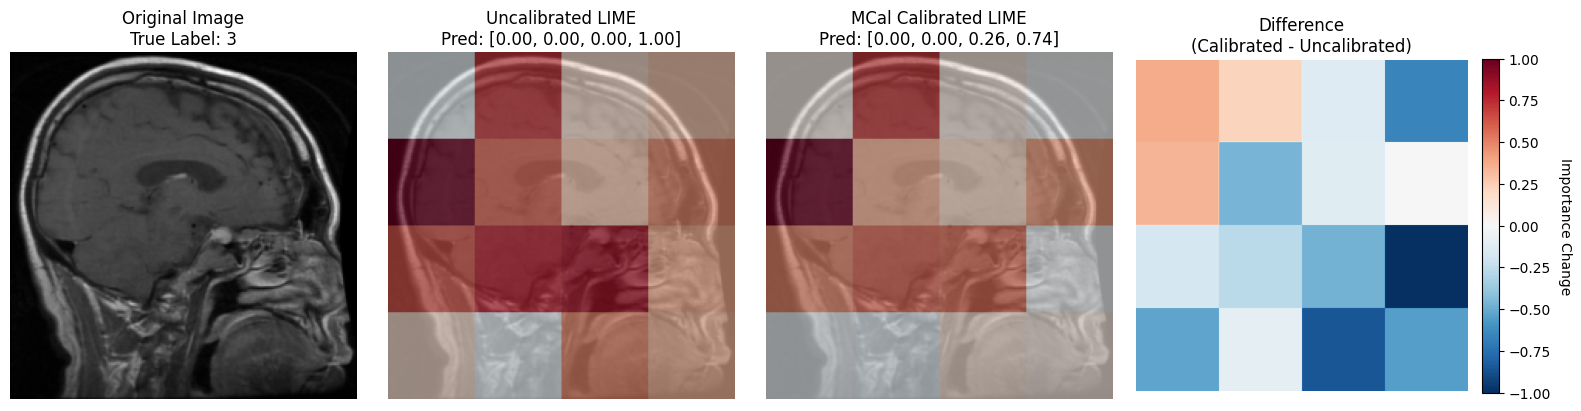


✓ All 16 visualizations saved to results/lime_visual_examples


In [12]:
# Generate and save visualizations for all test images
for i in range(len(test_images)):
    print(f"\nGenerating visualization for image {i+1}/{len(test_images)}...")
    
    fig = visualize_lime_comparison(
        idx=i,
        image=test_images[i],
        label=test_labels[i],
        uncal_importance=uncal_lime_attrs[i],
        calib_importance=calib_lime_attrs[i],
        uncal_model=uncal_model,
        calib_model=calib_model,
        patch_size=config['patch_size']
    )
    
    # Save figure
    output_file = output_dir / f'lime_comparison_image_{i:02d}.pdf'
    fig.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {output_file}")
    
    # Display in notebook
    plt.show()
    plt.close(fig)

print("\n" + "="*60)
print(f"✓ All {len(test_images)} visualizations saved to {output_dir}")

## 9. Summary Statistics

In [13]:
# Compute statistics on importance score changes
print("\n" + "="*60)
print("SUMMARY: Impact of MCal on LIME Importance Scores")
print("="*60)

# Calculate average absolute change in importance scores
avg_abs_changes = []
max_changes = []

for i in range(len(test_images)):
    diff = (calib_lime_attrs[i] - uncal_lime_attrs[i]).abs()
    avg_abs_changes.append(diff.mean().item())
    max_changes.append(diff.max().item())

print(f"\nAverage absolute change in importance scores:")
print(f"  Mean across all images: {np.mean(avg_abs_changes):.4f}")
print(f"  Std across all images: {np.std(avg_abs_changes):.4f}")
print(f"  Min: {np.min(avg_abs_changes):.4f}")
print(f"  Max: {np.max(avg_abs_changes):.4f}")

print(f"\nMaximum change per image:")
print(f"  Mean: {np.mean(max_changes):.4f}")
print(f"  Std: {np.std(max_changes):.4f}")

# Calculate correlation between uncalibrated and calibrated scores
correlations = []
for i in range(len(test_images)):
    uncal_np = uncal_lime_attrs[i].cpu().numpy()
    calib_np = calib_lime_attrs[i].cpu().numpy()
    corr = np.corrcoef(uncal_np, calib_np)[0, 1]
    correlations.append(corr)

print(f"\nCorrelation between uncalibrated and calibrated LIME scores:")
print(f"  Mean correlation: {np.mean(correlations):.4f}")
print(f"  Std correlation: {np.std(correlations):.4f}")

print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)
print("MCal modifies LIME explanations by adjusting the importance scores")
print("to account for missingness bias. The visualizations show:")
print("  - Red regions: MCal increases importance (features more relevant than uncal thinks)")
print("  - Blue regions: MCal decreases importance (features less relevant than uncal thinks)")
print("  - High correlation suggests MCal refines rather than completely changes explanations")
print("="*60)


SUMMARY: Impact of MCal on LIME Importance Scores

Average absolute change in importance scores:
  Mean across all images: 0.6295
  Std across all images: 0.3045
  Min: 0.2143
  Max: 1.1506

Maximum change per image:
  Mean: 1.8435
  Std: 1.1797

Correlation between uncalibrated and calibrated LIME scores:
  Mean correlation: 0.6464
  Std correlation: 0.4076

INTERPRETATION:
MCal modifies LIME explanations by adjusting the importance scores
to account for missingness bias. The visualizations show:
  - Red regions: MCal increases importance (features more relevant than uncal thinks)
  - Blue regions: MCal decreases importance (features less relevant than uncal thinks)
  - High correlation suggests MCal refines rather than completely changes explanations


## 10. Verify Output Files

In [14]:
# List all generated files
print("\nGenerated PDF files:")
print("=" * 40)

pdf_files = sorted(output_dir.glob('*.pdf'))
for pdf_file in pdf_files:
    size_kb = pdf_file.stat().st_size / 1024
    print(f"  {pdf_file.name:<35} ({size_kb:.1f} KB)")

print("=" * 40)
print(f"✓ Total: {len(pdf_files)} PDF files generated")


Generated PDF files:
  lime_comparison_image_00.pdf        (178.7 KB)
  lime_comparison_image_01.pdf        (205.7 KB)
  lime_comparison_image_02.pdf        (206.9 KB)
  lime_comparison_image_03.pdf        (233.9 KB)
  lime_comparison_image_04.pdf        (266.9 KB)
  lime_comparison_image_05.pdf        (213.1 KB)
  lime_comparison_image_06.pdf        (214.4 KB)
  lime_comparison_image_07.pdf        (214.8 KB)
  lime_comparison_image_08.pdf        (180.7 KB)
  lime_comparison_image_09.pdf        (208.5 KB)
  lime_comparison_image_10.pdf        (208.2 KB)
  lime_comparison_image_11.pdf        (232.9 KB)
  lime_comparison_image_12.pdf        (242.4 KB)
  lime_comparison_image_13.pdf        (202.8 KB)
  lime_comparison_image_14.pdf        (281.9 KB)
  lime_comparison_image_15.pdf        (267.1 KB)
✓ Total: 16 PDF files generated
